In [1]:
import numpy as np### math computations
import matplotlib.pyplot as plt### plotting bar chart
import cv2## image processing
import os## operating system
import random
import copy
from google.colab import files
import torch, torchvision
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
import albumentations as A
import torch.nn as nn
import torch.nn.functional as F

In [2]:
! pip install -q kaggle

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("iarunava/cell-images-for-detecting-malaria")

print("Path to dataset files:", path)

100%|██████████| 675M/675M [00:36<00:00, 19.2MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/iarunava/cell-images-for-detecting-malaria/versions/1


In [8]:
import os
import random

In [10]:
base_path = os.path.join(path, 'cell_images', 'cell_images')

train_paths_parasitized = []
train_paths_uninfected = []

train_paths_parasitized += os.listdir(os.path.join(base_path, 'Parasitized'))
train_paths_parasitized = [os.path.join(base_path, 'Parasitized', i) for i in train_paths_parasitized]

train_paths_uninfected += os.listdir(os.path.join(base_path, 'Uninfected'))
train_paths_uninfected = [os.path.join(base_path, 'Uninfected', i) for i in train_paths_uninfected]

paths = train_paths_parasitized + train_paths_uninfected

# Remove Thumbs.db if it exists, as it's not an image file
if os.path.exists(os.path.join(base_path, "Parasitized", "Thumbs.db")):
    paths.remove(os.path.join(base_path, "Parasitized", "Thumbs.db"))
if os.path.exists(os.path.join(base_path, "Uninfected", "Thumbs.db")):
    paths.remove(os.path.join(base_path, "Uninfected", "Thumbs.db"))

random.shuffle(paths)

FRACTION = 0.8
train_paths = paths[0:int(FRACTION*len(paths))]
val_paths = paths[int(FRACTION*len(paths)):]
print(len(val_paths), len(train_paths))

5512 22046


In [27]:
import cv2
from torch.utils.data import Dataset, DataLoader

class Malaria(Dataset):
  def __init__(self, image_filepaths, transform = None):
    self.image_filepaths = image_filepaths
    self.transform = transform

  def __len__(self):
    return len(self.image_filepaths)

  def __getitem__(self, index):

    image = cv2.imread(self.image_filepaths[index])

    if(self.image_filepaths[index].split('/')[1] == 'Parasitized'):
      label = 0.0
    else:
      label = 1.0


    if self.transform:
      image = self.transform(image = image)['image']

    return image, label

In [ ]:
#!pip install -U git+https://github.com/albu/albumentations --no-cache-dir

In [22]:
import albumentations as A

IM_SIZE = 224
transform = A.Compose([
    A.Resize(IM_SIZE, IM_SIZE),

    A.OneOf([A.HorizontalFlip(),
              A.VerticalFlip(),], p = 0.3),

    A.RandomRotate90(),
    A.RandomBrightnessContrast(brightness_limit=0.2,
                              contrast_limit=0.2, p=0.5),
    A.Normalize(),


])

In [23]:
train_dataset = Malaria(train_paths, transform)
val_dataset = Malaria(val_paths, transform)

In [24]:
BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size = BATCH_SIZE, shuffle = True)
val_loader = DataLoader(val_dataset, batch_size = BATCH_SIZE)

In [25]:
image, label = next(iter(train_loader))
print(image[2][100:150,100:150,0])

tensor([[0.6392, 0.6049, 0.6221,  ..., 0.5536, 0.5536, 0.5536],
        [0.6392, 0.6221, 0.6392,  ..., 0.5536, 0.5707, 0.5707],
        [0.6392, 0.6221, 0.6392,  ..., 0.5536, 0.5707, 0.5707],
        ...,
        [0.6221, 0.6392, 0.6221,  ..., 0.5707, 0.5707, 0.5707],
        [0.6392, 0.6563, 0.6392,  ..., 0.5364, 0.5536, 0.5536],
        [0.6563, 0.6734, 0.6563,  ..., 0.5364, 0.5364, 0.5364]])


tensor(1., dtype=torch.float64)


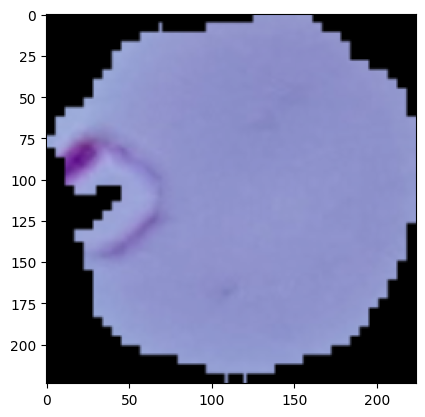

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# Convert the PyTorch tensor to a NumPy array
img_np = image[0].cpu().numpy()

# Unnormalize the image using common ImageNet mean and std values
# Albumentations' Normalize uses (img - mean) / std. To reverse: img * std + mean
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

unnormalized_img = img_np * std + mean

# Clip the values to the [0, 1] range for correct display
unnormalized_img = np.clip(unnormalized_img, 0, 1)

plt.imshow(unnormalized_img)
print(label[0])

In [33]:
import torch.nn as nn
import torch
import torch.nn.functional as F

class LeNet(nn.Module):
    def __init__(self):
      super(LeNet, self).__init__()

      self.conv1 = nn.Conv2d(in_channels=3, out_channels=6, kernel_size=3, stride=1, padding=1)
      self.bn1 = nn.BatchNorm2d(6)
      self.pool1 = nn.MaxPool2d(2,2)
      self.dropout1 = nn.Dropout2d(0.2)

      self.conv2 = nn.Conv2d(in_channels=6, out_channels=16, kernel_size=3, stride=1, padding=1)
      self.bn2 = nn.BatchNorm2d(16)
      self.pool2 = nn.MaxPool2d(2,2)

      self.fc3 = nn.Linear(50176, 100)
      self.bn3 = nn.BatchNorm1d(100)

      self.fc4 = nn.Linear(100, 10)
      self.bn4 = nn.BatchNorm1d(10)

      self.fc5 = nn.Linear(10, 1)

    def forward(self, input):

      output = self.dropout1(self.pool1(self.bn1(F.relu(self.conv1(input)))))
      output = self.pool2(self.bn2(F.relu(self.conv2(output))))

      output = output.reshape(-1, 16*56*56)
      output = self.bn3(F.relu(self.fc3(output)))
      output = self.bn4(F.relu(self.fc4(output)))

      output = torch.sigmoid(self.fc5(output))

      return output


model = LeNet()

model(torch.zeros((3,3,224,224)))

tensor([[0.5566],
        [0.5561],
        [0.5561]], grad_fn=<SigmoidBackward0>)

In [37]:
from torch.optim import Adam
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
loss_fn = torch.nn.BCELoss()
optimizer = Adam(model.parameters(), lr=1e-3, )

In [38]:
print(device)

cuda:0


In [39]:
def round(x):
  if(x>= 0.5):
    return 1.
  else:
    return 0.

In [40]:
def get_accuracy(epoch):
  model.eval()
  with torch.no_grad():
    epoch_accuracy = 0
    for i, (image, label) in enumerate(val_loader):
      image = torch.permute(image, (0,3,1,2))
      image = image.to(device)

      output = model(image)

      for i in range(len(output)):
        if(round(output[i].item()) == label[i].item()):
          epoch_accuracy += 1

  print("The Validation Accuracy for this epoch:{} is:{} ".format(epoch, 100*epoch_accuracy/len(val_dataset)))


In [41]:
def train(EPOCHS):

  model.to(device)

  for epoch in range(EPOCHS):
    epoch_loss = 0.0

    for i, (image, label) in enumerate(train_loader):

      image = torch.permute(image, (0,3,1,2))
      image = image.to(device)

      label = torch.unsqueeze(label, -1)
      label = label.float()
      label = label.to(device)

      optimizer.zero_grad()

      output = model(image)

      loss = loss_fn(output, label)

      loss.backward()
      optimizer.step()

      epoch_loss += loss.item()

      step_length = int(len(train_loader)/2)

      if(i%step_length) == 0:
              print('Epoch Number: {}, step: [{}|{}] ----> Loss: {}' .format(epoch+1, i, len(train_loader), loss.item()))
    print("Loss for epoch Number {} is :{}".format(epoch+1, epoch_loss/len(train_loader)))

    get_accuracy(epoch)


In [42]:
train(20)

Epoch Number: 1, step: [0|689] ----> Loss: 0.6277971863746643
Epoch Number: 1, step: [344|689] ----> Loss: 0.10251617431640625
Epoch Number: 1, step: [688|689] ----> Loss: 0.01922268606722355
Loss for epoch Number 1 is :0.19172057577007395
The Validation Accuracy for this epoch:0 is:100.0 
Epoch Number: 2, step: [0|689] ----> Loss: 0.019928982481360435
Epoch Number: 2, step: [344|689] ----> Loss: 5.155947292223573e-06
Epoch Number: 2, step: [688|689] ----> Loss: 4.450491246643651e-07
Loss for epoch Number 2 is :0.00013899131451747433
The Validation Accuracy for this epoch:1 is:100.0 
Epoch Number: 3, step: [0|689] ----> Loss: 1.8142329736292595e-06
Epoch Number: 3, step: [344|689] ----> Loss: 4.842883072342374e-07
Epoch Number: 3, step: [688|689] ----> Loss: 2.6226075533486437e-07
Loss for epoch Number 3 is :1.0074654710272828e-06
The Validation Accuracy for this epoch:2 is:100.0 
Epoch Number: 4, step: [0|689] ----> Loss: 3.2410054018328083e-07
Epoch Number: 4, step: [344|689] ----> L

### Retrain the model

The `train` function has already been defined and executed for 20 epochs. To retrain the model, you can call the `train` function again with your desired number of `EPOCHS`:

In [43]:
# Define the number of epochs for training
NUM_EPOCHS = 5

# Call the train function to start the training process
train(NUM_EPOCHS)

Epoch Number: 1, step: [0|689] ----> Loss: 0.0
Epoch Number: 1, step: [344|689] ----> Loss: 0.0
Epoch Number: 1, step: [688|689] ----> Loss: 0.0
Loss for epoch Number 1 is :8.110212388782716e-11
The Validation Accuracy for this epoch:0 is:100.0 
Epoch Number: 2, step: [0|689] ----> Loss: 0.0
Epoch Number: 2, step: [344|689] ----> Loss: 0.0
Epoch Number: 2, step: [688|689] ----> Loss: 0.0
Loss for epoch Number 2 is :5.947489106592047e-11
The Validation Accuracy for this epoch:1 is:100.0 
Epoch Number: 3, step: [0|689] ----> Loss: 0.0
Epoch Number: 3, step: [344|689] ----> Loss: 0.0
Epoch Number: 3, step: [688|689] ----> Loss: 0.0
Loss for epoch Number 3 is :5.947489299954548e-11
The Validation Accuracy for this epoch:2 is:100.0 
Epoch Number: 4, step: [0|689] ----> Loss: 0.0
Epoch Number: 4, step: [344|689] ----> Loss: 0.0
Epoch Number: 4, step: [688|689] ----> Loss: 0.0
Loss for epoch Number 4 is :4.3254466932896704e-11
The Validation Accuracy for this epoch:3 is:100.0 
Epoch Number: 5